In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
from dotenv import load_dotenv
load_dotenv()

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

pdf = PyPDFLoader("Why_Language_Models_Hallucinate_Explainer.pdf")
document = pdf.load()

text_splitter = RecursiveCharacterTextSplitter(chunk_overlap=120, chunk_size=1200)
pages = text_splitter.split_documents(documents=document)
chunks = [i.page_content for i in pages]

print(f"Total chunks: {len(chunks)}")

Total chunks: 10


In [2]:
import chromadb
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction

embedding_function = SentenceTransformerEmbeddingFunction(model_name="all-MiniLM-L6-v2")
client = chromadb.PersistentClient(path="./Local_data")

collection = client.get_or_create_collection(
    name="edumind",
    embedding_function=embedding_function
)

if collection.count() == 0:
    collection.add(
        documents=chunks,
        ids=[str(i) for i in range(len(chunks))],
        metadatas=[i.metadata for i in pages]
    )

print(f"Collection size: {collection.count()}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7219.47it/s]


Collection size: 10


In [3]:
from rank_bm25 import BM25Okapi

def tokenize(text: str):
    return text.lower().split()

tokenized_chunks = [tokenize(c) for c in chunks]
corpus_build = BM25Okapi(tokenized_chunks)

In [4]:
from langchain_groq import ChatGroq
import os 
from dotenv import  load_dotenv 
load_dotenv()
key = os.getenv("GROQ_API_KEY")
chat_model = ChatGroq(model="openai/gpt-oss-120b")

In [5]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage

class State(TypedDict):
    messages: Annotated[list, add_messages]
    context: str

In [6]:
def Retrival(state: State):
    query = state["messages"][-1].content

    response = collection.query(query_texts=[query], n_results=5)
    distances = response['distances'][0]
    documents = response['documents'][0]

    threshold = 0.8
    vector_chunks = [doc for dist, doc in zip(distances, documents) if dist < threshold]

    scores = corpus_build.get_scores(tokenize(query))
    ranked = sorted(enumerate(scores), key=lambda x: x[1], reverse=True)
    bm25_chunks = [chunks[i] for i, _ in ranked[:10]]   # bug fix: index -> actual text

    rrf_scores = {}
    for rank, doc in enumerate(vector_chunks):
        rrf_scores[doc] = rrf_scores.get(doc, 0) + 1 / (rank + 60)
    for rank, doc in enumerate(bm25_chunks):
        rrf_scores[doc] = rrf_scores.get(doc, 0) + 1 / (rank + 60)

    merged = sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)
    top_docs = [doc for doc, _ in merged[:5]]

    context_text = "\n\n".join(top_docs) if top_docs else ""
    return {"context": context_text}

In [7]:
from langchain_core.tools import tool
from tavily import TavilyClient

@tool
def web_search(query: str):
    """Search the web when the document context is insufficient to answer."""
    client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))
    response = client.search(query=query)
    return str(response)


import numexpr
@tool
def calculator(expression: str):
    """Evaluate a math expression, e.g. '47 * 12'."""
    try:
        result = numexpr.evaluate(expression).item()
        return str(result)
    except Exception as e:
        return f"Error: {e}"

tools = [web_search, calculator]
tool_blind = chat_model.bind_tools(tools)

In [8]:
def agent(state=State):
    return {"messages": tool_blind.invoke(state['messages'])}

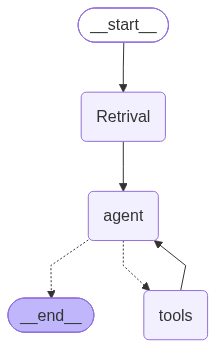

In [9]:
from langgraph.prebuilt import ToolNode, tools_condition

graph = StateGraph(State)
graph.add_node("Retrival", Retrival)
graph.add_node("agent", agent)
graph.add_node("tools", ToolNode(tools))

graph.add_edge(START, "Retrival")
graph.add_edge("Retrival", "agent")
graph.add_conditional_edges("agent", tools_condition)
graph.add_edge("tools", "agent")

response = graph.compile()
response

In [10]:
result = response.invoke({
    "messages": [HumanMessage(content="What is full form of LLM ?")],
    "context": ""
})
print(result['messages'][-1].content)

**LLM** most commonly stands for **“Large Language Model.”**  

In the context of artificial intelligence and natural‑language processing, a Large Language Model is a type of deep‑learning model (often based on transformer architectures) that has been trained on massive amounts of text data. It can generate, understand, translate, and reason about human language, powering tools like ChatGPT, Claude, Gemini, and many others.

---

### Other common meanings of “LLM”

| Acronym | Full Form | Domain |
|---------|-----------|--------|
| **LL.M.** | *Legum Magister* (Latin) – **Master of Laws** | Legal education (post‑graduate law degree) |
| **LLM** | *Low‑Level Machine* | Computing/embedded systems (rare) |
| **LLM** | *Local Loop Management* | Telecommunications (rare) |

If you were asking about the AI context, the answer is **Large Language Model**. If you meant a different field, let me know!


> SERVER

In [16]:
# only this mcp valid 
!uv pip install "mcp==1.9.4"

Checked 1 package in 36ms


In [17]:
from mcp.server.fastmcp import FastMCP
mcp = FastMCP(name="edumind")

import warnings
warnings.filterwarnings('ignore')

import os
from dotenv import load_dotenv
load_dotenv()

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

pdf = PyPDFLoader("Why_Language_Models_Hallucinate_Explainer.pdf")
document = pdf.load()

text_splitter = RecursiveCharacterTextSplitter(chunk_overlap=120, chunk_size=1200)
pages = text_splitter.split_documents(documents=document)
chunks = [i.page_content for i in pages]

print(f"Total chunks: {len(chunks)}")


import chromadb
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction

embedding_function = SentenceTransformerEmbeddingFunction(model_name="all-MiniLM-L6-v2")
client = chromadb.PersistentClient(path="./Local_data")

collection = client.get_or_create_collection(
    name="edumind",
    embedding_function=embedding_function
)

if collection.count() == 0:
    collection.add(
        documents=chunks,
        ids=[str(i) for i in range(len(chunks))],
        metadatas=[i.metadata for i in pages]
    )

print(f"Collection size: {collection.count()}") 

from rank_bm25 import BM25Okapi

def tokenize(text: str):
    return text.lower().split()

tokenized_chunks = [tokenize(c) for c in chunks]
corpus_build = BM25Okapi(tokenized_chunks)


from langchain_groq import ChatGroq
import os 
from dotenv import  load_dotenv 
load_dotenv()
key = os.getenv("GROQ_API_KEY")
chat_model = ChatGroq(model="openai/gpt-oss-120b")

# rewritten_query
@mcp.tool()
def Retrival(query:str):
    prompt = f""" make the prompt contextual : {query} """
    rewritten_query = chat_model.invoke(prompt).content

    response = collection.query(query_texts=[rewritten_query], n_results=5)
    distances = response['distances'][0]
    documents = response['documents'][0]

    threshold = 0.8
    vector_chunks = [doc for dist, doc in zip(distances, documents) if dist < threshold]

    scores = corpus_build.get_scores(tokenize(rewritten_query))
    ranked = sorted(enumerate(scores), key=lambda x: x[1], reverse=True)
    bm25_chunks = [chunks[i] for i, _ in ranked[:10]]   # bug fix: index -> actual text

    rrf_scores = {}
    for rank, doc in enumerate(vector_chunks):
        rrf_scores[doc] = rrf_scores.get(doc, 0) + 1 / (rank + 60)
    for rank, doc in enumerate(bm25_chunks):
        rrf_scores[doc] = rrf_scores.get(doc, 0) + 1 / (rank + 60)

    merged = sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)
    top_docs = [doc for doc, _ in merged[:5]]

    context_text = "\n\n".join(top_docs) if top_docs else ""
    return {"context": context_text}

Total chunks: 10
Collection size: 10
